#### save Stocks Codes

In [17]:
# '''extract all stock from baostock'''
# import baostock as bs
# import pandas as pd
# lg = bs.login()

# rs = bs.query_stock_basic()
# bs.logout()

# data = []
# while (rs.error_code == '0') and rs.next():
#     data.append(rs.get_row_data())
# df = pd.DataFrame(data, columns=rs.fields)
# bs.logout()
# df.to_csv("stock_list_20260314.csv", index=False, encoding="utf-8-sig")
# df

[Errno 9] Bad file descriptor
接收数据异常，请稍后再试。
[Errno 9] Bad file descriptor
接收数据异常，请稍后再试。


,code,code_name,ipoDate,outDate,type,status
0,sh.000002,上证A股指数,1992-02-21,,2,1
1,sh.000003,上证B股指数,1992-08-17,,2,1
2,sh.000004,上证工业类指数,1993-05-03,,2,1
3,sh.000005,上证商业类指数,1993-05-03,,2,1
4,sh.000006,上证房地产指数,1993-05-03,,2,1
...,...,...,...,...,...,...
8635,sz.399994,中证信息安全主题指数,2015-03-12,,2,1
8636,sz.399995,中证基建工程指数,2015-03-12,,2,1
8637,sz.399996,中证智能家居指数,2014-09-17,,2,1
8638,sz.399997,中证白酒指数,2015-01-21,,2,1


#### Choose Stock

In [ ]:
import numpy as np
import pandas as pd

"""
炒中期, 持仓1-3 month

Suitable for Grid Strategy:
    historical_volatility: 20%-50%   | too low no trade, too high trend following
    Avrage True Range:     1%-4%/day | ensure trades perday 
    Bollinger Bandwidth:   0.1-0.3   | (upper-lower)/ma = 4sigma/MA 中等震荡区间   | 太窄 - 横盘, 大行情前兆; 太宽 - 剧烈波动, 趋势行情
    Price Range Ratio:     30%-80%   | (N日最高价-N日最低价) / current price        | 有足够的空间设置网格
    Price percentile:      30%-70%   | 过去N天价格低于当前的天数/总天数               | 处于高位的话慎买

"""
def pass_fundamental_screening(isst):
    # 剔除ST、*ST、市值<50亿的标的
    # 基本面过滤(无退市风险，连续盈利>=2yr)
    if np.nanmax(isst.astype(float)) > 0.5:  # =1: is ST
        return False
    return True


def _Index_screening(yz,  atr_abs, atr_pct,  bb,  prr,  ppercent):
    '''排除错误选项, 剩下的就是正确的'''
    if np.nanmax(yz)>0.5:    # 波动率  # np.nanmin(yz)<0.2
        return False
    if np.nanmin(atr_pct)<0.01 or np.nanmax(atr_pct)>0.05:
        return False
    if np.nanmin(prr)< 0.30 or np.nanmax(prr)>0.80:    # Price Range Ratio: 有足够的空间设置网格
        return False
    if np.nanmax(ppercent)>0.70:    # Price percentile: 目前处于区间中部，才能入场 ppercent<0.30 or 
        return False
    # 流动性确认: 日均成交额>5000万, 保证网格能成交

    return True

In [9]:
ds = pd.read_csv("stock_list_20260314.csv", dtype=str)  # 8640 lines
'''type 1-stock, 2-Index, 3-else(ETF.etc)
    status 1-listed上市中, 0-delisted已退市'''
stockList = ds[(ds["type"].isin(["1", "2", "3"])) 
                & (ds["status"] == "1") 
                & (ds["ipoDate"] < "2025-01-01")]  # 只关注上市>1年的
stockList  # 5653 lines

,code,code_name,ipoDate,outDate,type,status
0,sh.000002,上证A股指数,1992-02-21,NaN,2,1
1,sh.000003,上证B股指数,1992-08-17,NaN,2,1
2,sh.000004,上证工业类指数,1993-05-03,NaN,2,1
3,sh.000005,上证商业类指数,1993-05-03,NaN,2,1
4,sh.000006,上证房地产指数,1993-05-03,NaN,2,1
...,...,...,...,...,...,...
8635,sz.399994,中证信息安全主题指数,2015-03-12,NaN,2,1
8636,sz.399995,中证基建工程指数,2015-03-12,NaN,2,1
8637,sz.399996,中证智能家居指数,2014-09-17,NaN,2,1
8638,sz.399997,中证白酒指数,2015-01-21,NaN,2,1


In [ ]:
from util_BackTestM import extract_data
from util_Index import volatility_indicators

# stockIndex = "sz.000713"
startDate = "2021-10-16"  # "2004-08-19"
endDate = "2026-03-08"    # "2013-03-01"

stock_choose = []
for stockindex in (stockList["code"]):  ###
    df = extract_data(stockIndex=stockindex, start_date=startDate, end_date=endDate)    # 1990-12-19 to now
    print(f'{stockindex} extracted')

    # ## fundamental screening
    if not pass_fundamental_screening(df["isst"]):
        continue

    open, high, low, close = df['open'], df['high'], df['low'], df['close']
    yz,  atr_abs, atr_pct,  bb,  prr,  ppercent = volatility_indicators(open, high, low, close, draw=False)
    if _Index_screening(yz,  atr_abs, atr_pct,  bb,  prr,  ppercent):
        print(f"{stockindex} append")
        stock_choose.append(stockindex)
        
stock_choose

login success!
login respond error_code:0, error_msg:success
query_history_k_data_plus respond error_code=0, error_msg=success
logout success!
sh.000002 extracted
login success!
login respond error_code:0, error_msg:success
query_history_k_data_plus respond error_code=0, error_msg=success
logout success!
sh.000003 extracted
login success!
login respond error_code:0, error_msg:success
query_history_k_data_plus respond error_code=0, error_msg=success
logout success!
sh.000004 extracted
login success!
login respond error_code:0, error_msg:success
query_history_k_data_plus respond error_code=0, error_msg=success
logout success!
sh.000005 extracted
login success!
login respond error_code:0, error_msg:success
query_history_k_data_plus respond error_code=0, error_msg=success
logout success!
sh.000006 extracted
login success!
login respond error_code:0, error_msg:success
query_history_k_data_plus respond error_code=0, error_msg=success
logout success!
sh.000007 extracted
login success!
login r

/var/folders/hh/rk7k5wd10tsbp89h33gph84h0000gn/T/ipykernel_83242/2536640308.py:22: RuntimeWarning: All-NaN axis encountered
  if np.nanmin(yz)<0.2 or np.nanmax(yz)>0.5:   # 波动率
/var/folders/hh/rk7k5wd10tsbp89h33gph84h0000gn/T/ipykernel_83242/2536640308.py:24: RuntimeWarning: All-NaN axis encountered
  if np.nanmin(atr_pct)<0.01 or np.nanmax(atr_pct)>0.05:
/var/folders/hh/rk7k5wd10tsbp89h33gph84h0000gn/T/ipykernel_83242/2536640308.py:26: RuntimeWarning: All-NaN axis encountered
  if np.nanmin(prr)< 0.30 or np.nanmax(prr)>0.80:    # Price Range Ratio: 有足够的空间设置网格
/var/folders/hh/rk7k5wd10tsbp89h33gph84h0000gn/T/ipykernel_83242/2536640308.py:28: RuntimeWarning: All-NaN axis encountered
  if np.nanmax(ppercent)>0.70:    # Price percentile: 目前处于区间中部，才能入场 ppercent<0.30 or


login success!
login respond error_code:0, error_msg:success
query_history_k_data_plus respond error_code=0, error_msg=success
logout success!
sh.600000 extracted
login success!
login respond error_code:0, error_msg:success
query_history_k_data_plus respond error_code=0, error_msg=success
logout success!
sh.600004 extracted
login success!
login respond error_code:0, error_msg:success
query_history_k_data_plus respond error_code=0, error_msg=success
logout success!
sh.600006 extracted
login success!
login respond error_code:0, error_msg:success
query_history_k_data_plus respond error_code=0, error_msg=success
logout success!
sh.600007 extracted
login success!
login respond error_code:0, error_msg:success
query_history_k_data_plus respond error_code=0, error_msg=success
logout success!
sh.600008 extracted
login success!
login respond error_code:0, error_msg:success
query_history_k_data_plus respond error_code=0, error_msg=success
logout success!
sh.600009 extracted
login success!
login r

KeyboardInterrupt: 

In [16]:
stock_choose

['sh.000999']

In [1]:
from util_Index import volatility_indicators

login success!
logout success!
           date       code  open  high  low  close  volume isst
0    2021-10-18  sh.000999   NaN   NaN  NaN    NaN     NaN    0
1    2021-10-19  sh.000999   NaN   NaN  NaN    NaN     NaN    0
2    2021-10-20  sh.000999   NaN   NaN  NaN    NaN     NaN    0
3    2021-10-21  sh.000999   NaN   NaN  NaN    NaN     NaN    0
4    2021-10-22  sh.000999   NaN   NaN  NaN    NaN     NaN    0
..          ...        ...   ...   ...  ...    ...     ...  ...
817  2025-03-03  sh.000999   NaN   NaN  NaN    NaN     NaN    0
818  2025-03-04  sh.000999   NaN   NaN  NaN    NaN     NaN    0
819  2025-03-05  sh.000999   NaN   NaN  NaN    NaN     NaN    0
820  2025-03-06  sh.000999   NaN   NaN  NaN    NaN     NaN    0
821  2025-03-07  sh.000999   NaN   NaN  NaN    NaN     NaN    0

[822 rows x 8 columns]


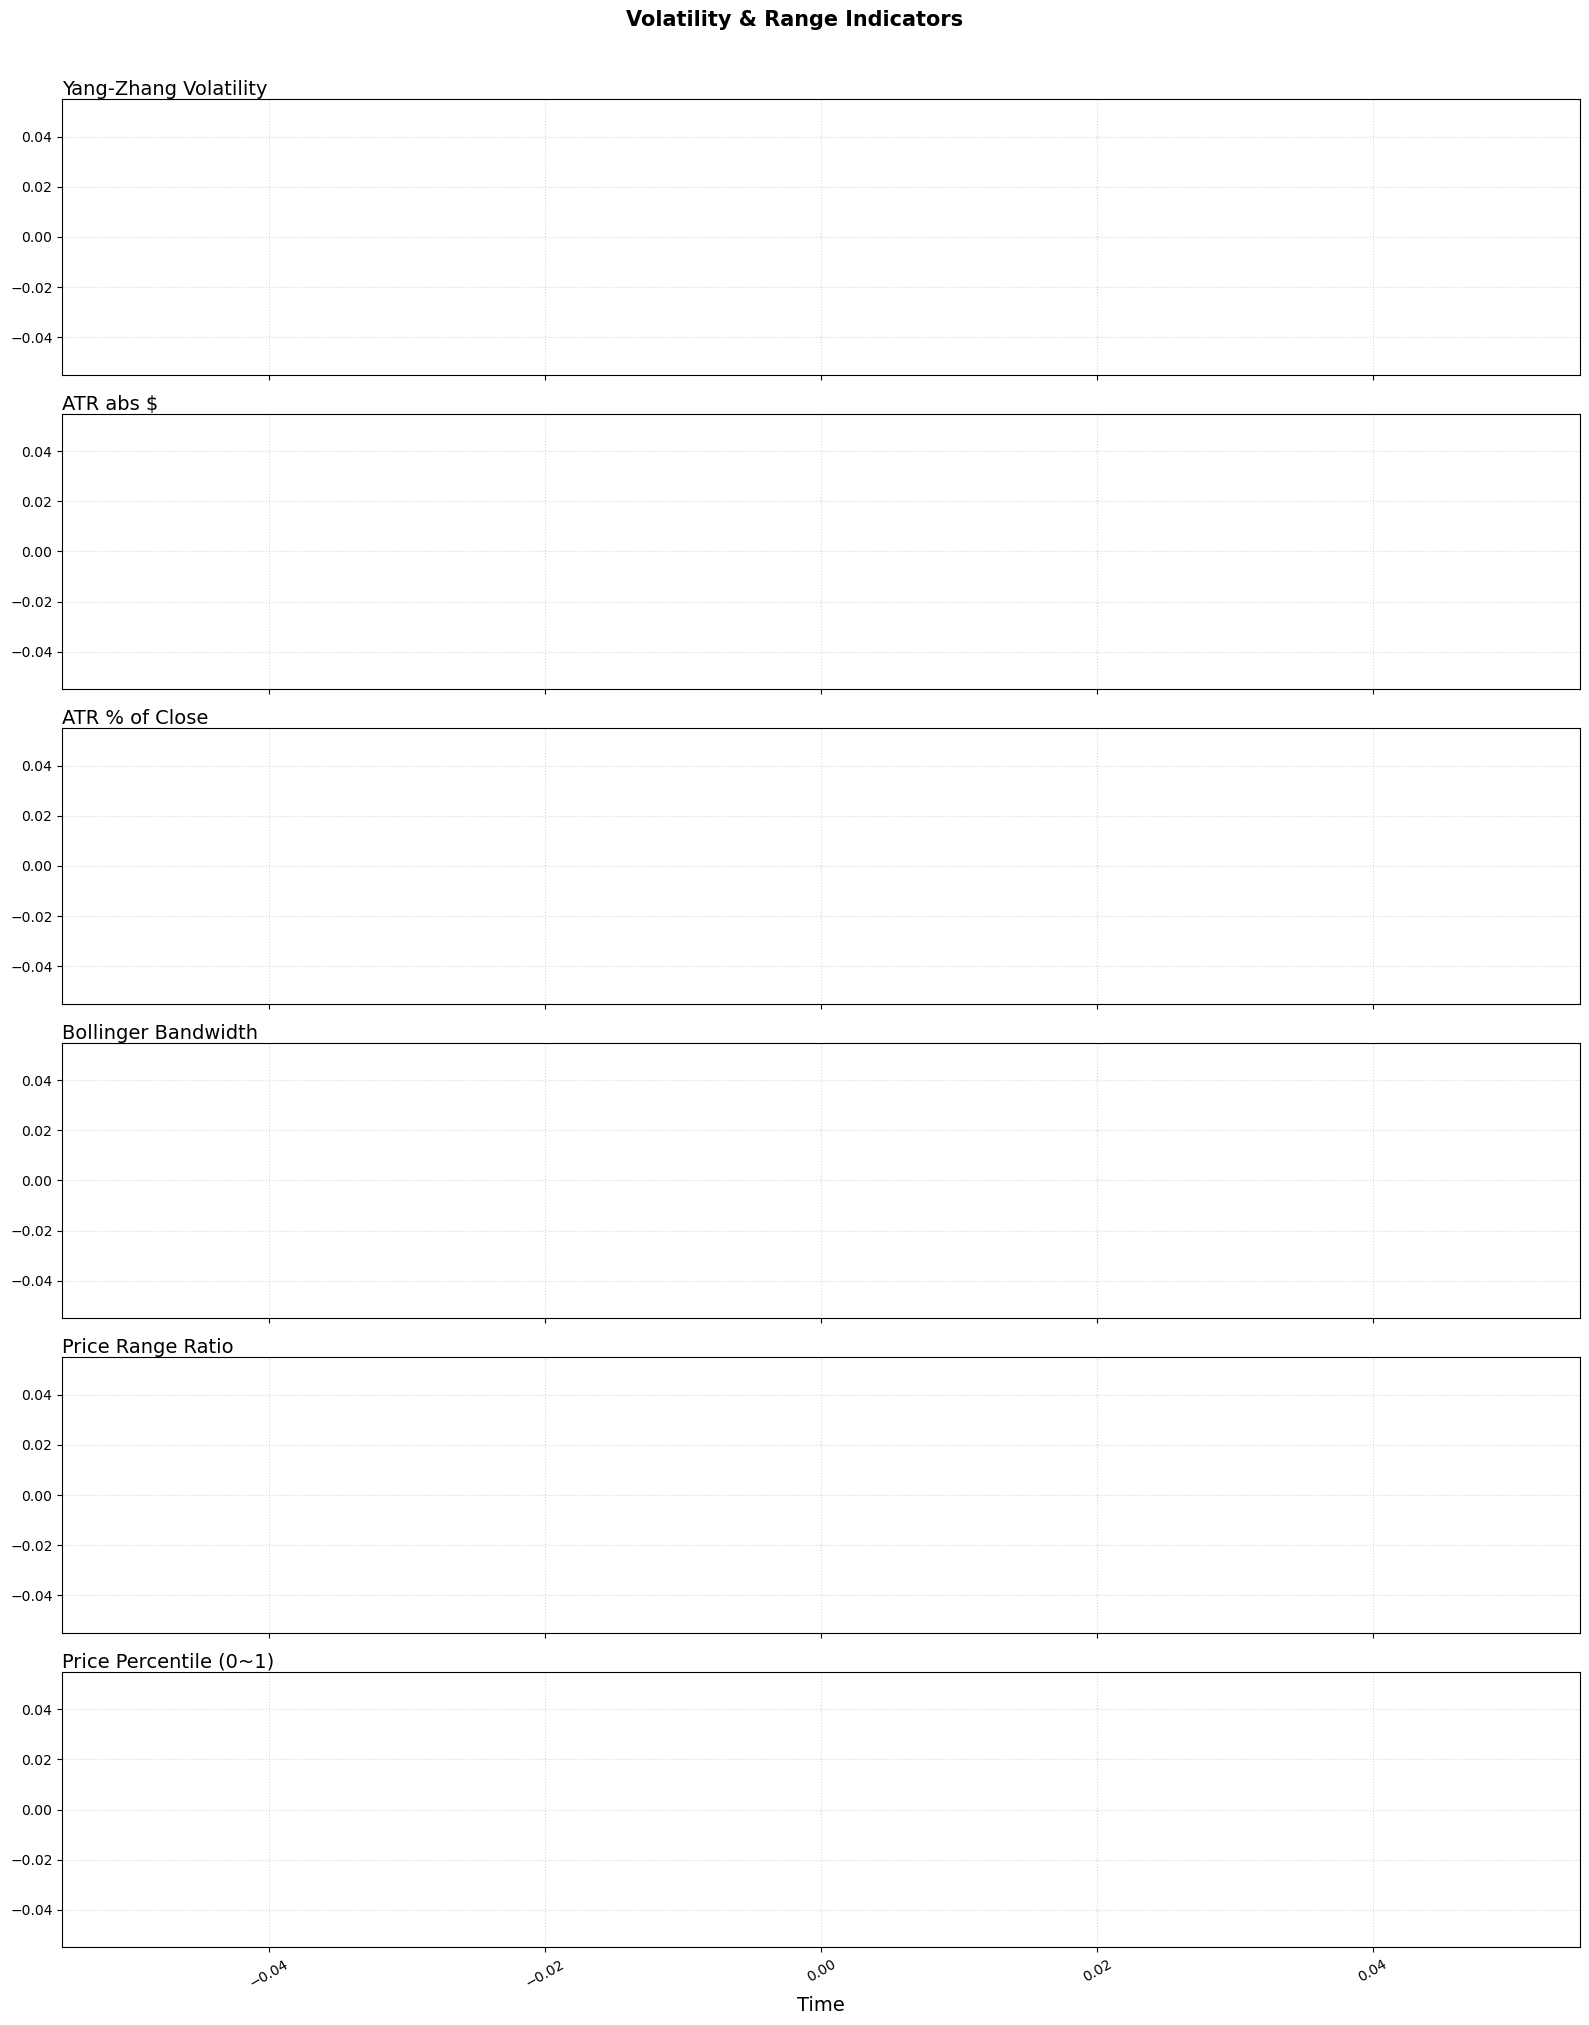

In [6]:
# # 选sz.000713，计算各个指标保证量级和理解没问题
# from util_BackTestM import extract_data

# stockindex = "sh.000999"  #"sz.000713"
startDate = "2021-10-18"  # "2004-08-19"
endDate = "2025-03-08"    # "2013-03-01"
df = extract_data(stockIndex=stockindex, start_date=startDate, end_date=endDate)    # 1990-12-19 to now
print(df)

open, high, low, close = df['open'], df['high'], df['low'], df['close']
yz,  atr_abs, atr_pct,  bb,  prr,  ppercent = volatility_indicators(open, high, low, close, draw=True)

In [ ]:
yz,  atr_abs, atr_pct,  bb,  prr,  ppercent = volatility_indicators(open, high, low, close, draw=False)
np.nanmin(yz)

np.float64(0.04966203422717076)

In [ ]:
# 广泛筛选
# 虚拟盘验证